# BERT Mental Health Classification — Hyperparameter & Context-Length Comparison

This notebook fine-tunes **`bert-base-uncased`** on a 7-class mental-health text-classification
dataset and compares **13 configurations** across two context lengths (256 and 512 tokens),
varying batch size, learning rate, warmup, weight decay, label smoothing, and early stopping.

**max_length = 256 models**
- **A — Baseline:** lr=2e-5, effective batch=8, 3 epochs
- **B — Larger Batch:** lr=2e-5, effective batch=32 (8×4), 3 epochs
- **C — Early Stopping:** lr=2e-5, effective batch=8, up to 5 epochs (patience=2)
- **D — Lower LR + Regularized:** lr=1e-5, effective batch=16, weight_decay=0.05, warmup=0.1, up to 5 epochs
- **E — Larger Batch + Lower LR:** lr=1e-5, effective batch=32, 3 epochs

**max_length = 512 models**
- **F — Baseline (512):** lr=2e-5, effective batch=8, 3 epochs
- **G — Baseline (512):** lr=2e-5, effective batch=8, 3 epochs
- **H — Larger Batch (512):** lr=2e-5, effective batch=32, 3 epochs
- **I — Early Stopping (512):** lr=2e-5, effective batch=8, up to 5 epochs
- **M — Larger Batch + Higher LR (512):** lr=3e-5, effective batch=32, 3 epochs
- **N — Label Smoothing (512):** lr=2e-5, effective batch=8, label_smoothing=0.05, 3 epochs
- **O — Warmup (512):** lr=2e-5, effective batch=8, warmup_ratio=0.1, 3 epochs
- **P — Lower LR (512):** lr=1.5e-5, effective batch=8, 3 epochs

All models use standard CrossEntropyLoss (Model N adds label smoothing) and are evaluated with
weighted Accuracy, Precision, Recall, and F1 on a held-out test set.

In [ ]:
!pip install -q datasets pandas matplotlib seaborn transformers accelerate scikit-learn

import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


## 1. Load Data & EDA

In [ ]:
ds = load_dataset("sai1908/Mental_Health_Condition_Classification")
df = ds["train"].to_pandas()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nClass distribution:")
print(df["status"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/791 [00:00<?, ?B/s]

Mental Health Text Dataset for Emotion a(…):   0%|          | 0.00/46.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/103488 [00:00<?, ? examples/s]

Shape: (103488, 2)
Columns: ['text', 'status']
Nulls: 0
Duplicates: 0

Class distribution:
status
anxiety                 17620
normal                  16068
depression              15901
stress                  15230
personality disorder    13915
bipolar                 13708
suicidal                11046
Name: count, dtype: int64


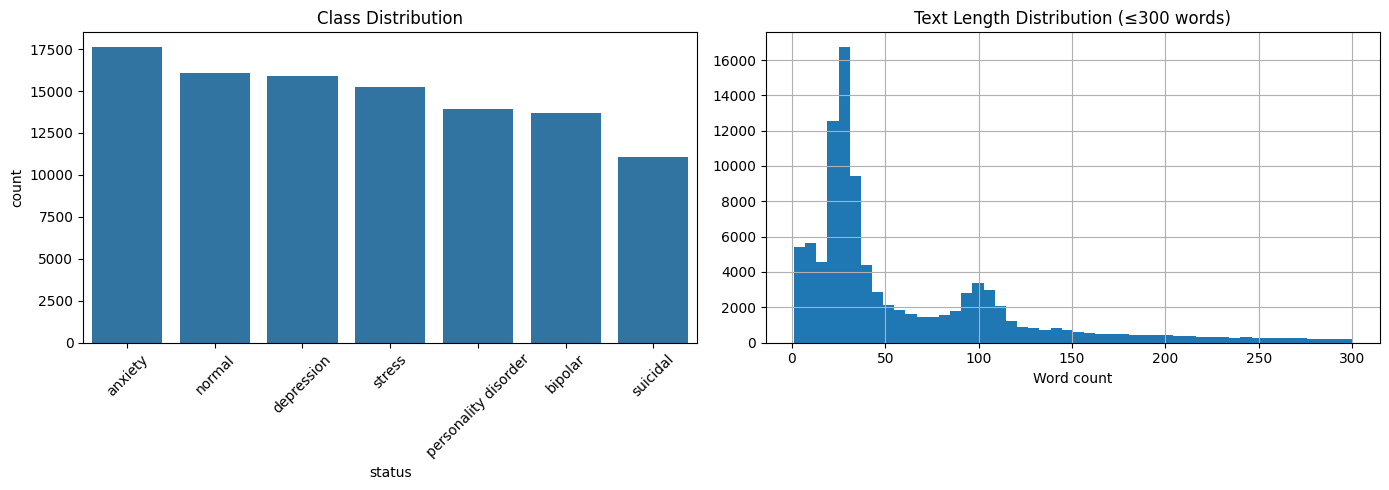

count    103488.000000
mean         82.019365
std         127.863250
min           1.000000
25%          24.000000
50%          34.000000
75%          99.000000
max        5419.000000
Name: word_length, dtype: float64

Texts > 256 words: 6600 (6.38%)


In [ ]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="status", order=df["status"].value_counts().index, ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].tick_params(axis="x", rotation=45)

# Text length distribution
df["word_length"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df[df["word_length"] <= 300]["word_length"].hist(bins=50, ax=axes[1])
axes[1].set_title("Text Length Distribution (≤300 words)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()

print(df["word_length"].describe())
print(f"\nTexts > 256 words: {(df['word_length'] > 256).sum()} ({(df['word_length'] > 256).mean()*100:.2f}%)")

## 2. Preprocessing

In [ ]:
# Clean text (light cleaning only — BERT handles raw language well)
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

# Encode labels
labels = sorted(df["status"].unique())
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for label, idx in label2id.items()}
df["label"] = df["status"].map(label2id)
num_labels = len(labels)

print(f"Classes: {labels}")
print(f"Samples after cleaning: {len(df):,}")

Classes: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
Samples after cleaning: 103,487


## 3. Train / Validation / Test Split (80/10/10)

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["clean_text", "label"]]),
    "validation": Dataset.from_pandas(val_df[["clean_text", "label"]]),
    "test": Dataset.from_pandas(test_df[["clean_text", "label"]])
})
dataset = dataset.rename_column("clean_text", "text")

for split in dataset:
    if "__index_level_0__" in dataset[split].column_names:
        dataset = dataset.remove_columns(["__index_level_0__"])

Train: 82,789  |  Val: 10,349  |  Test: 10,349


## 4. Tokenization (max_length = 256)

Tokenize the dataset at `max_length = 256` for the first group of models (A–E).
The 512-token models are re-tokenized separately in Section 7.

In [ ]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

tokenized_dataset = dataset.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

token_lengths = [len(x) for x in tokenized_dataset["train"]["input_ids"]]
print(f"Token lengths — Min: {min(token_lengths)}, Max: {max(token_lengths)}, "
      f"Mean: {np.mean(token_lengths):.0f}, Median: {np.median(token_lengths):.0f}")
print(f"Truncated to 256: {sum(1 for l in token_lengths if l == 256):,} "
      f"({sum(1 for l in token_lengths if l == 256)/len(token_lengths)*100:.1f}%)")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Token lengths — Min: 3, Max: 256, Mean: 84, Median: 47
Truncated to 256: 6,825 (8.2%)


## 5. Evaluation Function

In [ ]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels_true, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

target_names = [id2label[i] for i in range(num_labels)]
print("Ready. Target names:", target_names)

Ready. Target names: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']


## 6. Model Training Experiments

The cells below fine-tune and evaluate every configuration. Each model is trained from a fresh
`bert-base-uncased` checkpoint with a fixed seed (42), then evaluated on the validation and test
splits, with a per-class classification report stored for analysis.

| Group | Model | Max Len | Eff. Batch | LR | Key Setting | Epochs |
|---|---|---|---|---|---|---|
| 256 | A_baseline | 256 | 8 | 2e-5 | — | 3 fixed |
| 256 | B_larger_batch | 256 | 32 | 2e-5 | gradient accumulation ×4 | 3 fixed |
| 256 | C_early_stopping | 256 | 8 | 2e-5 | early stopping, patience=2 | up to 5 |
| 256 | D_lower_lr_regularized | 256 | 16 | 1e-5 | weight_decay=0.05, warmup=0.1 | up to 5 |
| 256 | E_larger_batch_lower_lr | 256 | 32 | 1e-5 | larger batch + lower LR | 3 fixed |
| 512 | F_baseline_max_length_512 | 512 | 8 | 2e-5 | longer context | 3 fixed |
| 512 | G_baseline_512 | 512 | 8 | 2e-5 | longer context | 3 fixed |
| 512 | H_larger_batch_512 | 512 | 32 | 2e-5 | gradient accumulation | 3 fixed |
| 512 | I_early_stopping_512 | 512 | 8 | 2e-5 | early stopping | up to 5 |
| 512 | M_larger_batch_higher_lr_512 | 512 | 32 | 3e-5 | larger batch + scaled LR | 3 fixed |
| 512 | N_label_smoothing_512 | 512 | 8 | 2e-5 | label_smoothing=0.05 | 3 fixed |
| 512 | O_warmup_512 | 512 | 8 | 2e-5 | warmup_ratio=0.1 | 3 fixed |
| 512 | P_lr_15e6_512 | 512 | 8 | 1.5e-5 | slightly lower LR | 3 fixed |

### 6.1 Models A–D — Core variants (max_length = 256)

Trains four 256-token configurations in one loop: **A** (baseline), **B** (larger effective batch
of 32 via gradient accumulation), **C** (early stopping, up to 5 epochs), and **D** (lower learning
rate with stronger weight decay and warmup). Results are collected into a comparison table sorted by Test F1.

In [ ]:
# ============================================================
# BERT Fine-Tuning Experiments: A, B, C, D
# Metrics: Accuracy, Precision, Recall, F1-score
# ============================================================

import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# ============================================================
# 1. Set seed for reproducibility
# ============================================================

set_seed(42)

# Make sure target names follow label ID order
target_names = [id2label[i] for i in range(len(id2label))]

# ============================================================
# 2. Define evaluation metrics
# ============================================================

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels_true, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ============================================================
# 3. Define model configurations
# ============================================================

model_configs = {
    "A_baseline": {
        "description": "Baseline BERT fine-tuning",
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "gradient_accumulation_steps": 1,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "B_larger_batch": {
        "description": "Larger effective batch size using gradient accumulation",
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "gradient_accumulation_steps": 4,
        "effective_batch_size": 32,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "C_early_stopping": {
        "description": "Early stopping with maximum 5 epochs",
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "gradient_accumulation_steps": 1,
        "effective_batch_size": 8,
        "num_train_epochs": 5,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "early_stopping": True,
        "early_stopping_patience": 2,
    },

    "D_lower_lr_regularized": {
        "description": "Lower learning rate with stronger regularization and warmup",
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 16,
        "num_train_epochs": 5,
        "learning_rate": 1e-5,
        "weight_decay": 0.05,
        "warmup_ratio": 0.1,
        "early_stopping": True,
        "early_stopping_patience": 2,
    },
}

# ============================================================
# 4. Storage for results
# ============================================================

all_results = {}
all_reports = {}

# ============================================================
# 5. Train and evaluate each model
# ============================================================

for name, cfg in model_configs.items():

    print("\n" + "=" * 80)
    print(f"Training: {name}")
    print(f"Description: {cfg['description']}")
    print(
        f"Batch size: {cfg['per_device_train_batch_size']} x "
        f"{cfg['gradient_accumulation_steps']} = "
        f"{cfg['effective_batch_size']} effective batch size"
    )
    print(f"Learning rate: {cfg['learning_rate']}")
    print(f"Weight decay: {cfg['weight_decay']}")
    print(f"Warmup ratio: {cfg['warmup_ratio']}")
    print(
        f"Epochs: {'up to ' if cfg['early_stopping'] else ''}"
        f"{cfg['num_train_epochs']}"
        f"{' with early stopping' if cfg['early_stopping'] else ' fixed'}"
    )
    print("=" * 80)

    # Clear memory before each experiment
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Fresh model for each experiment
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )

    # Training arguments
    args = TrainingArguments(
    output_dir=f"./{name}",

        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=cfg["learning_rate"],
        warmup_ratio=cfg["warmup_ratio"],
        weight_decay=cfg["weight_decay"],

        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        num_train_epochs=cfg["num_train_epochs"],

        logging_steps=200,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",

        fp16=torch.cuda.is_available(),

        seed=42,
        data_seed=42,
    )

    # Early stopping callback
    callbacks = []

    if cfg["early_stopping"]:
        callbacks.append(
            EarlyStoppingCallback(
                early_stopping_patience=cfg["early_stopping_patience"]
            )
        )

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
    )

    # Fine-tune model
    train_result = trainer.train()

    # Evaluate on validation set
    val_metrics = trainer.evaluate(tokenized_dataset["validation"])

    # Evaluate on test set
    test_metrics = trainer.evaluate(tokenized_dataset["test"])

    # Generate prediction for classification report
    pred_output = trainer.predict(tokenized_dataset["test"])

    y_pred = np.argmax(pred_output.predictions, axis=1)
    y_true = pred_output.label_ids

    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )

    # Store results
    all_results[name] = {
        "Model": name,
        "Description": cfg["description"],
        "Learning Rate": cfg["learning_rate"],
        "Weight Decay": cfg["weight_decay"],
        "Warmup Ratio": cfg["warmup_ratio"],
        "Train Batch Size": cfg["per_device_train_batch_size"],
        "Gradient Accumulation": cfg["gradient_accumulation_steps"],
        "Effective Batch Size": cfg["effective_batch_size"],
        "Configured Epochs": cfg["num_train_epochs"],
        "Completed Epochs": train_result.metrics.get("epoch"),
        "Early Stopping": cfg["early_stopping"],

        "Train Loss": train_result.training_loss,

        "Validation Loss": val_metrics["eval_loss"],
        "Validation Accuracy": val_metrics["eval_accuracy"],
        "Validation Precision": val_metrics["eval_precision"],
        "Validation Recall": val_metrics["eval_recall"],
        "Validation F1": val_metrics["eval_f1"],

        "Test Loss": test_metrics["eval_loss"],
        "Test Accuracy": test_metrics["eval_accuracy"],
        "Test Precision": test_metrics["eval_precision"],
        "Test Recall": test_metrics["eval_recall"],
        "Test F1": test_metrics["eval_f1"],

        "Best Checkpoint": trainer.state.best_model_checkpoint,
    }

    all_reports[name] = report

    print("\nResult Summary")
    print(f"{name}")
    print(f"Validation F1 : {val_metrics['eval_f1']:.4f}")
    print(f"Test F1       : {test_metrics['eval_f1']:.4f}")
    print(f"Test Accuracy : {test_metrics['eval_accuracy']:.4f}")

    # Clear model from memory before next experiment
    del trainer
    del model

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# 6. Compare all model results
# ============================================================

print("\n\n" + "=" * 80)
print("ALL TRAINING COMPLETE")
print("=" * 80)

results_df = pd.DataFrame(all_results).T.reset_index(drop=True)

# Sort by Test F1
results_df_sorted = results_df.sort_values("Test F1", ascending=False)

display(results_df_sorted)

# Show best model
best_model_row = results_df_sorted.iloc[0]

print("\nBest Model:")
print(best_model_row[["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]])


Training: A_baseline
Description: Baseline BERT fine-tuning
Batch size: 8 x 1 = 8 effective batch size
Learning rate: 2e-05
Weight decay: 0.01
Warmup ratio: 0.0
Epochs: 3 fixed


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.243737,0.278719,0.909363,0.909484,0.909363,0.908603
2,0.220576,0.291259,0.913132,0.914124,0.913132,0.913130
3,0.103072,0.355491,0.916707,0.917353,0.916707,0.916794


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.172217,0.387001,5,0.914581,0.914862,0.914581,0.914569


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.172217,0.388354,5,0.915741,0.915792,0.915741,0.915689



Result Summary
D_lower_lr_regularized
Validation F1 : 0.9146
Test F1       : 0.9157
Test Accuracy : 0.9157


ALL TRAINING COMPLETE


,Model,Description,Learning Rate,Weight Decay,Warmup Ratio,Train Batch Size,Gradient Accumulation,Effective Batch Size,Configured Epochs,Completed Epochs,...,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Best Checkpoint
0,A_baseline,Baseline BERT fine-tuning,0.00002,0.01,0.0,8,1,8,3,3.0,...,0.916707,0.917353,0.916707,0.916794,0.363053,0.918736,0.91901,0.918736,0.918689,./A_baseline/checkpoint-31047
1,B_larger_batch,Larger effective batch size using gradient acc...,0.00002,0.01,0.0,8,4,32,3,3.0,...,0.918543,0.918803,0.918543,0.918575,0.250278,0.917577,0.91721,0.917577,0.917336,./B_larger_batch/checkpoint-7764
3,D_lower_lr_regularized,Lower learning rate with stronger regularizati...,0.00001,0.05,0.1,8,2,16,5,5.0,...,0.914581,0.914862,0.914581,0.914569,0.388354,0.915741,0.915792,0.915741,0.915689,./D_lower_lr_regularized/checkpoint-25875
2,C_early_stopping,Early stopping with maximum 5 epochs,0.00002,0.01,0.0,8,1,8,5,5.0,...,0.909846,0.910221,0.909846,0.909948,0.557643,0.911682,0.911441,0.911682,0.911531,./C_early_stopping/checkpoint-51745



Best Model:
Model             A_baseline
Test Accuracy       0.918736
Test Precision       0.91901
Test Recall         0.918736
Test F1             0.918689
Name: 0, dtype: object


### 6.2 Model E — Larger batch + lower learning rate (max_length = 256)

A standalone run combining the larger effective batch (32) with a lower learning rate (1e-5) at 256 tokens.

In [ ]:
# ============================================================
# Model E Only: Larger Effective Batch + Lower Learning Rate
# Same as Model B, but learning_rate = 1e-5
# ============================================================

import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import classification_report

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

set_seed(42)

# Make sure target names follow label ID order
target_names = [id2label[i] for i in range(len(id2label))]

# ------------------------------------------------------------
# 2. Clear memory
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 3. Model E configuration
# ------------------------------------------------------------

name = "E_larger_batch_lower_lr"

cfg = {
    "description": "Larger effective batch size with lower learning rate",
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 16,
    "gradient_accumulation_steps": 4,  # effective batch = 8 x 4 = 32
    "effective_batch_size": 32,
    "num_train_epochs": 3,
    "learning_rate": 1e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.0,
    "early_stopping": False,
}

print("\n" + "=" * 80)
print(f"Training: {name}")
print(f"Description: {cfg['description']}")
print(f"Batch size: {cfg['per_device_train_batch_size']} x {cfg['gradient_accumulation_steps']} = {cfg['effective_batch_size']} effective batch size")
print(f"Learning rate: {cfg['learning_rate']}")
print(f"Weight decay: {cfg['weight_decay']}")
print(f"Epochs: {cfg['num_train_epochs']}")
print("=" * 80)

# ------------------------------------------------------------
# 4. Load fresh BERT model
# ------------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# ------------------------------------------------------------
# 5. Training arguments
# ------------------------------------------------------------

args = TrainingArguments(
    output_dir=f"./{name}",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=cfg["learning_rate"],
    warmup_ratio=cfg["warmup_ratio"],
    weight_decay=cfg["weight_decay"],

    per_device_train_batch_size=cfg["per_device_train_batch_size"],
    per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
    gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

    num_train_epochs=cfg["num_train_epochs"],

    logging_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42,
    data_seed=42,
)

# ------------------------------------------------------------
# 6. Trainer
# ------------------------------------------------------------

trainer_E = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ------------------------------------------------------------
# 7. Fine-tune Model E
# ------------------------------------------------------------

train_result_E = trainer_E.train()

# ------------------------------------------------------------
# 8. Evaluate Model E
# ------------------------------------------------------------

val_metrics_E = trainer_E.evaluate(tokenized_dataset["validation"])
test_metrics_E = trainer_E.evaluate(tokenized_dataset["test"])

print("\nValidation Results:")
print(val_metrics_E)

print("\nTest Results:")
print(test_metrics_E)

# ------------------------------------------------------------
# 9. Classification report
# ------------------------------------------------------------

pred_output_E = trainer_E.predict(tokenized_dataset["test"])

y_pred_E = np.argmax(pred_output_E.predictions, axis=1)
y_true_E = pred_output_E.label_ids

report_E = classification_report(
    y_true_E,
    y_pred_E,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_E_df = pd.DataFrame(report_E).T

print("\nClassification Report for Model E:")
display(report_E_df)

# ------------------------------------------------------------
# 10. Store Model E result
# ------------------------------------------------------------

model_E_result = {
    "Model": name,
    "Description": cfg["description"],
    "Learning Rate": cfg["learning_rate"],
    "Weight Decay": cfg["weight_decay"],
    "Warmup Ratio": cfg["warmup_ratio"],
    "Train Batch Size": cfg["per_device_train_batch_size"],
    "Gradient Accumulation": cfg["gradient_accumulation_steps"],
    "Effective Batch Size": cfg["effective_batch_size"],
    "Configured Epochs": cfg["num_train_epochs"],
    "Completed Epochs": train_result_E.metrics.get("epoch"),
    "Train Loss": train_result_E.training_loss,

    "Validation Loss": val_metrics_E["eval_loss"],
    "Validation Accuracy": val_metrics_E["eval_accuracy"],
    "Validation Precision": val_metrics_E["eval_precision"],
    "Validation Recall": val_metrics_E["eval_recall"],
    "Validation F1": val_metrics_E["eval_f1"],

    "Test Loss": test_metrics_E["eval_loss"],
    "Test Accuracy": test_metrics_E["eval_accuracy"],
    "Test Precision": test_metrics_E["eval_precision"],
    "Test Recall": test_metrics_E["eval_recall"],
    "Test F1": test_metrics_E["eval_f1"],
}

model_E_result_df = pd.DataFrame([model_E_result])

display(model_E_result_df)


Training: E_larger_batch_lower_lr
Description: Larger effective batch size with lower learning rate
Batch size: 8 x 4 = 32 effective batch size
Learning rate: 1e-05
Weight decay: 0.01
Epochs: 3


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.038615,0.236209,0.908977,0.911337,0.908977,0.908846
2,0.782369,0.228320,0.914678,0.914188,0.914678,0.914353
3,0.629466,0.230542,0.915547,0.916266,0.915547,0.915584


...

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.629466,0.238380,3,0.916997,0.917446,0.916997,0.916990



Validation Results:
{'eval_loss': 0.23054192960262299, 'eval_accuracy': 0.9155473958836603, 'eval_precision': 0.9162662036146385, 'eval_recall': 0.9155473958836603, 'eval_f1': 0.9155835350687613}

Test Results:
{'eval_loss': 0.23837999999523163, 'eval_accuracy': 0.9169968112861147, 'eval_precision': 0.9174460803656569, 'eval_recall': 0.9169968112861147, 'eval_f1': 0.9169899855489008}



Classification Report for Model E:


,precision,recall,f1-score,support
anxiety,0.960179,0.971623,0.965867,1762.000000
bipolar,0.970888,0.973012,0.971949,1371.000000
depression,0.823056,0.772327,0.796885,1590.000000
normal,0.953903,0.965775,0.959802,1607.000000
personality disorder,0.984772,0.975575,0.980152,1392.000000
stress,0.954395,0.948129,0.951252,1523.000000
suicidal,0.729890,0.780797,0.754486,1104.000000
accuracy,0.916997,0.916997,0.916997,0.916997
macro avg,0.911012,0.912463,0.911485,10349.000000
weighted avg,0.917446,0.916997,0.916990,10349.000000


,Model,Description,Learning Rate,Weight Decay,Warmup Ratio,Train Batch Size,Gradient Accumulation,Effective Batch Size,Configured Epochs,Completed Epochs,...,Validation Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1
0,E_larger_batch_lower_lr,Larger effective batch size with lower learnin...,0.00001,0.01,0.0,8,4,32,3,3.0,...,0.230542,0.915547,0.916266,0.915547,0.915584,0.23838,0.916997,0.917446,0.916997,0.91699


## 7. Extending Context to max_length = 512

The following sections re-tokenize the data at 512 tokens and re-run the key configurations to test
whether longer context improves performance.

### 7.1 Re-tokenization at 512 tokens

Rebuilds the tokenized dataset (`tokenized_dataset_F`) at `max_length = 512`. Truncation drops from
8.2% of training texts (256 tokens) to about 2.3% (512 tokens).

In [ ]:
# ============================================================
# Tokenization for Model F: max_length = 512
# ============================================================

from transformers import AutoTokenizer, DataCollatorWithPadding
import numpy as np

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length_F = 512

def tokenize_fn_F(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length_F
    )

tokenized_dataset_F = dataset.map(tokenize_fn_F, batched=True)

data_collator_F = DataCollatorWithPadding(tokenizer=tokenizer)

token_lengths_F = [len(x) for x in tokenized_dataset_F["train"]["input_ids"]]

print(
    f"Token lengths — Min: {min(token_lengths_F)}, "
    f"Max: {max(token_lengths_F)}, "
    f"Mean: {np.mean(token_lengths_F):.0f}, "
    f"Median: {np.median(token_lengths_F):.0f}"
)

print(
    f"Truncated to 512: {sum(1 for l in token_lengths_F if l == 512):,} "
    f"({sum(1 for l in token_lengths_F if l == 512) / len(token_lengths_F) * 100:.1f}%)"
)

Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Token lengths — Min: 3, Max: 512, Mean: 95, Median: 47
Truncated to 512: 1,914 (2.3%)


### 7.2 Model F — Baseline at max_length = 512

Model A's baseline settings (lr=2e-5, effective batch=8, 3 epochs) applied to 512-token inputs,
to isolate the effect of longer context.

In [ ]:
# ============================================================
# Model F: Same as Model A, but max_length = 512
# Purpose: Test whether longer text context improves BERT performance
# ============================================================

import os
import shutil
import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import classification_report

# ------------------------------------------------------------
# 1. Set seed
# ------------------------------------------------------------

set_seed(42)

# ------------------------------------------------------------
# 2. Clear memory
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 3. Model F configuration
# ------------------------------------------------------------

name = "F_baseline_max_length_512"

max_length_F = 512

cfg_F = {
    "description": "Model A baseline setting with max_length = 512",
    "per_device_train_batch_size": 4,      # reduced because 512 tokens uses more GPU memory
    "per_device_eval_batch_size": 8,
    "gradient_accumulation_steps": 2,      # effective batch = 4 x 2 = 8, same as Model A
    "effective_batch_size": 8,
    "num_train_epochs": 3,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.0,
}

print("\n" + "=" * 80)
print(f"Training: {name}")
print(f"Description: {cfg_F['description']}")
print(f"Max length: {max_length_F}")
print(
    f"Batch size: {cfg_F['per_device_train_batch_size']} x "
    f"{cfg_F['gradient_accumulation_steps']} = "
    f"{cfg_F['effective_batch_size']} effective batch size"
)
print(f"Learning rate: {cfg_F['learning_rate']}")
print(f"Weight decay: {cfg_F['weight_decay']}")
print(f"Epochs: {cfg_F['num_train_epochs']}")
print("=" * 80)

# ------------------------------------------------------------
# 4. Retokenize dataset with max_length = 512
# ------------------------------------------------------------

def tokenize_function_F(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length_F
    )

tokenized_dataset_F = dataset.map(
    tokenize_function_F,
    batched=True
)

# Dynamic padding for Model F
data_collator_F = DataCollatorWithPadding(tokenizer=tokenizer)

# Check token length
token_lengths_F = [len(x) for x in tokenized_dataset_F["train"]["input_ids"]]

print("\nToken Length Summary for Model F")
print("Minimum token length:", min(token_lengths_F))
print("Maximum token length:", max(token_lengths_F))
print("Average token length:", sum(token_lengths_F) / len(token_lengths_F))

# ------------------------------------------------------------
# 5. Remove old output folder if it exists
# ------------------------------------------------------------

if os.path.exists(f"./{name}"):
    shutil.rmtree(f"./{name}")

# ------------------------------------------------------------
# 6. Load fresh BERT model
# ------------------------------------------------------------

model_F = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# ------------------------------------------------------------
# 7. Training arguments
# ------------------------------------------------------------

args_F = TrainingArguments(
    output_dir=f"./{name}",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=cfg_F["learning_rate"],
    warmup_ratio=cfg_F["warmup_ratio"],
    weight_decay=cfg_F["weight_decay"],

    per_device_train_batch_size=cfg_F["per_device_train_batch_size"],
    per_device_eval_batch_size=cfg_F["per_device_eval_batch_size"],
    gradient_accumulation_steps=cfg_F["gradient_accumulation_steps"],

    num_train_epochs=cfg_F["num_train_epochs"],

    logging_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42,
    data_seed=42,
)

# ------------------------------------------------------------
# 8. Trainer
# ------------------------------------------------------------

trainer_F = Trainer(
    model=model_F,
    args=args_F,
    train_dataset=tokenized_dataset_F["train"],
    eval_dataset=tokenized_dataset_F["validation"],
    processing_class=tokenizer,
    data_collator=data_collator_F,
    compute_metrics=compute_metrics,
)

# ------------------------------------------------------------
# 9. Fine-tune Model F
# ------------------------------------------------------------

train_result_F = trainer_F.train()

# ------------------------------------------------------------
# 10. Evaluate Model F
# ------------------------------------------------------------

val_metrics_F = trainer_F.evaluate(tokenized_dataset_F["validation"])
test_metrics_F = trainer_F.evaluate(tokenized_dataset_F["test"])

print("\nValidation Results:")
print(val_metrics_F)

print("\nTest Results:")
print(test_metrics_F)

# ------------------------------------------------------------
# 11. Classification report
# ------------------------------------------------------------

pred_output_F = trainer_F.predict(tokenized_dataset_F["test"])

y_pred_F = np.argmax(pred_output_F.predictions, axis=1)
y_true_F = pred_output_F.label_ids

target_names = [id2label[i] for i in range(len(id2label))]

report_F = classification_report(
    y_true_F,
    y_pred_F,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_F_df = pd.DataFrame(report_F).T

print("\nClassification Report for Model F:")
display(report_F_df)

# ------------------------------------------------------------
# 12. Store Model F result
# ------------------------------------------------------------

model_F_result = {
    "Model": name,
    "Description": cfg_F["description"],
    "Max Length": max_length_F,
    "Learning Rate": cfg_F["learning_rate"],
    "Weight Decay": cfg_F["weight_decay"],
    "Warmup Ratio": cfg_F["warmup_ratio"],
    "Train Batch Size": cfg_F["per_device_train_batch_size"],
    "Gradient Accumulation": cfg_F["gradient_accumulation_steps"],
    "Effective Batch Size": cfg_F["effective_batch_size"],
    "Configured Epochs": cfg_F["num_train_epochs"],
    "Completed Epochs": train_result_F.metrics.get("epoch"),
    "Train Loss": train_result_F.training_loss,

    "Validation Loss": val_metrics_F["eval_loss"],
    "Validation Accuracy": val_metrics_F["eval_accuracy"],
    "Validation Precision": val_metrics_F["eval_precision"],
    "Validation Recall": val_metrics_F["eval_recall"],
    "Validation F1": val_metrics_F["eval_f1"],

    "Test Loss": test_metrics_F["eval_loss"],
    "Test Accuracy": test_metrics_F["eval_accuracy"],
    "Test Precision": test_metrics_F["eval_precision"],
    "Test Recall": test_metrics_F["eval_recall"],
    "Test F1": test_metrics_F["eval_f1"],
}

model_F_result_df = pd.DataFrame([model_F_result])

display(model_F_result_df)


Training: F_baseline_max_length_512
Description: Model A baseline setting with max_length = 512
Max length: 512
Batch size: 4 x 2 = 8 effective batch size
Learning rate: 2e-05
Weight decay: 0.01
Epochs: 3


Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]


Token Length Summary for Model F
Minimum token length: 3
Maximum token length: 512
Average token length: 95.36068801410815


...

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.220773,0.405923,3,0.919799,0.919705,0.919799,0.919704



Validation Results:
{'eval_loss': 0.39126405119895935, 'eval_accuracy': 0.918542854382066, 'eval_precision': 0.9189138742162274, 'eval_recall': 0.918542854382066, 'eval_f1': 0.9186048891535565}

Test Results:
{'eval_loss': 0.4059225618839264, 'eval_accuracy': 0.9197990143975263, 'eval_precision': 0.9197050399098116, 'eval_recall': 0.9197990143975263, 'eval_f1': 0.9197044367178752}



Classification Report for Model F:


,precision,recall,f1-score,support
anxiety,0.962444,0.974461,0.968415,1762.000000
bipolar,0.966040,0.975201,0.970599,1371.000000
depression,0.818123,0.794969,0.806380,1590.000000
normal,0.961395,0.960797,0.961096,1607.000000
personality disorder,0.981214,0.975575,0.978386,1392.000000
stress,0.955805,0.951412,0.953603,1523.000000
suicidal,0.752212,0.769928,0.760967,1104.000000
accuracy,0.919799,0.919799,0.919799,0.919799
macro avg,0.913890,0.914620,0.914206,10349.000000
weighted avg,0.919705,0.919799,0.919704,10349.000000


,Model,Description,Max Length,Learning Rate,Weight Decay,Warmup Ratio,Train Batch Size,Gradient Accumulation,Effective Batch Size,Configured Epochs,...,Validation Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1
0,F_baseline_max_length_512,Model A baseline setting with max_length = 512,512,0.00002,0.01,0.0,4,2,8,3,...,0.391264,0.918543,0.918914,0.918543,0.918605,0.405923,0.919799,0.919705,0.919799,0.919704


### 7.3 Models G, H, I — 512-token variants

Three 512-token configurations in one loop: **G** (baseline, a repeat of F to gauge run-to-run
variance), **H** (larger effective batch of 32), and **I** (early stopping, up to 5 epochs).

In [ ]:
# ============================================================
# BERT Fine-Tuning Experiments: G, H, I
# All models use max_length = 512 tokens
# Metrics: Accuracy, Precision, Recall, F1-score
# ============================================================

import os
import shutil
import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# ============================================================
# 1. Set seed for reproducibility
# ============================================================

set_seed(42)

target_names = [id2label[i] for i in range(len(id2label))]

# ============================================================
# 2. Tokenization with max_length = 512
# ============================================================

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length_512 = 512

def tokenize_fn_512(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length_512
    )

tokenized_dataset_512 = dataset.map(
    tokenize_fn_512,
    batched=True
)

data_collator_512 = DataCollatorWithPadding(tokenizer=tokenizer)

# Check token length
token_lengths_512 = [
    len(x) for x in tokenized_dataset_512["train"]["input_ids"]
]

print(
    f"Token lengths — Min: {min(token_lengths_512)}, "
    f"Max: {max(token_lengths_512)}, "
    f"Mean: {np.mean(token_lengths_512):.0f}, "
    f"Median: {np.median(token_lengths_512):.0f}"
)

print(
    f"Truncated to 512: {sum(1 for l in token_lengths_512 if l == 512):,} "
    f"({sum(1 for l in token_lengths_512 if l == 512) / len(token_lengths_512) * 100:.1f}%)"
)

# ============================================================
# 3. Define evaluation metrics
# ============================================================

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels_true, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ============================================================
# 4. Define Model G, H, I configurations
# ============================================================

model_configs_512 = {
    "G_baseline_512": {
        "description": "Baseline BERT fine-tuning with max_length = 512",
        "max_length": 512,

        # Original Model A effective batch = 8
        # For 512 tokens, reduce physical batch size to avoid GPU memory issue
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,

        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,

        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "H_larger_batch_512": {
        "description": "Larger effective batch size with max_length = 512",
        "max_length": 512,

        # Original Model B effective batch = 32
        # For 512 tokens: 4 x 8 = 32
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 8,
        "effective_batch_size": 32,

        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,

        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "I_early_stopping_512": {
        "description": "Early stopping with max_length = 512",
        "max_length": 512,

        # Same effective batch as baseline
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,

        "num_train_epochs": 5,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,

        "early_stopping": True,
        "early_stopping_patience": 2,
    },
}

# ============================================================
# 5. Storage for results
# ============================================================

all_results_512 = {}
all_reports_512 = {}

# ============================================================
# 6. Train and evaluate each model
# ============================================================

for name, cfg in model_configs_512.items():

    print("\n" + "=" * 80)
    print(f"Training: {name}")
    print(f"Description: {cfg['description']}")
    print(f"Max length: {cfg['max_length']}")
    print(
        f"Batch size: {cfg['per_device_train_batch_size']} x "
        f"{cfg['gradient_accumulation_steps']} = "
        f"{cfg['effective_batch_size']} effective batch size"
    )
    print(f"Learning rate: {cfg['learning_rate']}")
    print(f"Weight decay: {cfg['weight_decay']}")
    print(f"Warmup ratio: {cfg['warmup_ratio']}")
    print(
        f"Epochs: {'up to ' if cfg['early_stopping'] else ''}"
        f"{cfg['num_train_epochs']}"
        f"{' with early stopping' if cfg['early_stopping'] else ' fixed'}"
    )
    print("=" * 80)

    # Clear memory before each experiment
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Remove old output folder if exists
    if os.path.exists(f"./{name}"):
        shutil.rmtree(f"./{name}")

    # Fresh model for each experiment
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )

    # Training arguments
    args = TrainingArguments(
        output_dir=f"./{name}",

        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=cfg["learning_rate"],
        warmup_ratio=cfg["warmup_ratio"],
        weight_decay=cfg["weight_decay"],

        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        num_train_epochs=cfg["num_train_epochs"],

        logging_steps=200,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",

        fp16=torch.cuda.is_available(),

        seed=42,
        data_seed=42,
    )

    # Early stopping callback
    callbacks = []

    if cfg["early_stopping"]:
        callbacks.append(
            EarlyStoppingCallback(
                early_stopping_patience=cfg["early_stopping_patience"]
            )
        )

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_dataset_512["train"],
        eval_dataset=tokenized_dataset_512["validation"],
        processing_class=tokenizer,
        data_collator=data_collator_512,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
    )

    # Fine-tune model
    train_result = trainer.train()

    # Evaluate on validation set
    val_metrics = trainer.evaluate(tokenized_dataset_512["validation"])

    # Evaluate on test set
    test_metrics = trainer.evaluate(tokenized_dataset_512["test"])

    # Generate prediction for classification report
    pred_output = trainer.predict(tokenized_dataset_512["test"])

    y_pred = np.argmax(pred_output.predictions, axis=1)
    y_true = pred_output.label_ids

    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )

    # Store results
    all_results_512[name] = {
        "Model": name,
        "Description": cfg["description"],
        "Max Length": cfg["max_length"],
        "Learning Rate": cfg["learning_rate"],
        "Weight Decay": cfg["weight_decay"],
        "Warmup Ratio": cfg["warmup_ratio"],

        "Train Batch Size": cfg["per_device_train_batch_size"],
        "Gradient Accumulation": cfg["gradient_accumulation_steps"],
        "Effective Batch Size": cfg["effective_batch_size"],

        "Configured Epochs": cfg["num_train_epochs"],
        "Completed Epochs": train_result.metrics.get("epoch"),
        "Early Stopping": cfg["early_stopping"],

        "Train Loss": train_result.training_loss,

        "Validation Loss": val_metrics["eval_loss"],
        "Validation Accuracy": val_metrics["eval_accuracy"],
        "Validation Precision": val_metrics["eval_precision"],
        "Validation Recall": val_metrics["eval_recall"],
        "Validation F1": val_metrics["eval_f1"],

        "Test Loss": test_metrics["eval_loss"],
        "Test Accuracy": test_metrics["eval_accuracy"],
        "Test Precision": test_metrics["eval_precision"],
        "Test Recall": test_metrics["eval_recall"],
        "Test F1": test_metrics["eval_f1"],

        "Best Checkpoint": trainer.state.best_model_checkpoint,
    }

    all_reports_512[name] = report

    print("\nResult Summary")
    print(f"{name}")
    print(f"Validation F1 : {val_metrics['eval_f1']:.4f}")
    print(f"Test F1       : {test_metrics['eval_f1']:.4f}")
    print(f"Test Accuracy : {test_metrics['eval_accuracy']:.4f}")

    # Clear model from memory before next experiment
    del trainer
    del model

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# 7. Compare all Model G, H, I results
# ============================================================

print("\n\n" + "=" * 80)
print("ALL 512-TOKEN TRAINING COMPLETE")
print("=" * 80)

results_df_512 = pd.DataFrame(all_results_512).T.reset_index(drop=True)

results_df_512_sorted = results_df_512.sort_values("Test F1", ascending=False)

display(results_df_512_sorted)

# Show best model
best_model_row_512 = results_df_512_sorted.iloc[0]

print("\nBest 512-token Model:")
print(best_model_row_512[["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]])

Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Token lengths — Min: 3, Max: 512, Mean: 95, Median: 47
Truncated to 512: 1,914 (2.3%)

Training: G_baseline_512
Description: Baseline BERT fine-tuning with max_length = 512
Max length: 512
Batch size: 4 x 2 = 8 effective batch size
Learning rate: 2e-05
Weight decay: 0.01
Warmup ratio: 0.0
Epochs: 3 fixed


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.100413,0.514766,5,0.912649,0.913011,0.912649,0.912735


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.100413,0.485143,5,0.919509,0.919573,0.919509,0.919502



Result Summary
I_early_stopping_512
Validation F1 : 0.9127
Test F1       : 0.9195
Test Accuracy : 0.9195


ALL 512-TOKEN TRAINING COMPLETE


,Model,Description,Max Length,Learning Rate,Weight Decay,Warmup Ratio,Train Batch Size,Gradient Accumulation,Effective Batch Size,Configured Epochs,...,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Best Checkpoint
0,G_baseline_512,Baseline BERT fine-tuning with max_length = 512,512,0.00002,0.01,0.0,4,2,8,3,...,0.918929,0.919497,0.918929,0.919038,0.392952,0.922021,0.922125,0.922021,0.921971,./G_baseline_512/checkpoint-31047
2,I_early_stopping_512,Early stopping with max_length = 512,512,0.00002,0.01,0.0,4,2,8,5,...,0.912649,0.913011,0.912649,0.912735,0.485143,0.919509,0.919573,0.919509,0.919502,./I_early_stopping_512/checkpoint-41396
1,H_larger_batch_512,Larger effective batch size with max_length = 512,512,0.00002,0.01,0.0,4,8,32,3,...,0.918929,0.919363,0.918929,0.918921,0.251551,0.919413,0.919364,0.919413,0.919223,./H_larger_batch_512/checkpoint-7764



Best 512-token Model:
Model             G_baseline_512
Test Accuracy           0.922021
Test Precision          0.922125
Test Recall             0.922021
Test F1                 0.921971
Name: 0, dtype: object


### 7.4 Model M — Larger batch + higher learning rate (512)

Same larger effective batch (32) as Model H, but with the learning rate scaled up to 3e-5
(the linear-scaling intuition that bigger batches need bigger steps).

In [ ]:
# ============================================================
# Model M Only:
# Same as Model H, but with higher learning rate
# Includes tokenization with max_length = 512
# ============================================================

import os
import shutil
import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# ------------------------------------------------------------
# 1. Set seed for reproducibility
# ------------------------------------------------------------

set_seed(42)

target_names = [id2label[i] for i in range(len(id2label))]

# ------------------------------------------------------------
# 2. Define evaluation metrics
# ------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels_true, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# 3. Tokenization with max_length = 512
# ------------------------------------------------------------

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length_M = 512

def tokenize_fn_M(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length_M
    )

tokenized_dataset_M = dataset.map(
    tokenize_fn_M,
    batched=True
)

data_collator_M = DataCollatorWithPadding(tokenizer=tokenizer)

# Check token length
token_lengths_M = [
    len(x) for x in tokenized_dataset_M["train"]["input_ids"]
]

print(
    f"Token lengths — Min: {min(token_lengths_M)}, "
    f"Max: {max(token_lengths_M)}, "
    f"Mean: {np.mean(token_lengths_M):.0f}, "
    f"Median: {np.median(token_lengths_M):.0f}"
)

print(
    f"Truncated to 512: {sum(1 for l in token_lengths_M if l == 512):,} "
    f"({sum(1 for l in token_lengths_M if l == 512) / len(token_lengths_M) * 100:.1f}%)"
)

# ------------------------------------------------------------
# 4. Clear memory
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 5. Model M configuration
# ------------------------------------------------------------

name = "M_H_larger_batch_higher_lr_512"

cfg = {
    "description": "Same as Model H with larger learning rate",
    "max_length": 512,

    # Same as Model H
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 8,
    "gradient_accumulation_steps": 8,
    "effective_batch_size": 32,

    "num_train_epochs": 3,

    # Higher than Model H
    "learning_rate": 3e-5,

    "weight_decay": 0.01,
    "warmup_ratio": 0.0,
}

print("\n" + "=" * 80)
print(f"Training: {name}")
print(f"Description: {cfg['description']}")
print(f"Max length: {cfg['max_length']}")
print(
    f"Batch size: {cfg['per_device_train_batch_size']} x "
    f"{cfg['gradient_accumulation_steps']} = "
    f"{cfg['effective_batch_size']} effective batch size"
)
print(f"Learning rate: {cfg['learning_rate']}")
print(f"Weight decay: {cfg['weight_decay']}")
print(f"Warmup ratio: {cfg['warmup_ratio']}")
print(f"Epochs: {cfg['num_train_epochs']}")
print("=" * 80)

# ------------------------------------------------------------
# 6. Remove old output folder if exists
# ------------------------------------------------------------

if os.path.exists(f"./{name}"):
    shutil.rmtree(f"./{name}")

# ------------------------------------------------------------
# 7. Load fresh BERT model
# ------------------------------------------------------------

model_M = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# ------------------------------------------------------------
# 8. Training arguments
# ------------------------------------------------------------

args_M = TrainingArguments(
    output_dir=f"./{name}",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=cfg["learning_rate"],
    warmup_ratio=cfg["warmup_ratio"],
    weight_decay=cfg["weight_decay"],

    per_device_train_batch_size=cfg["per_device_train_batch_size"],
    per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
    gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

    num_train_epochs=cfg["num_train_epochs"],

    logging_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42,
    data_seed=42,
)

# ------------------------------------------------------------
# 9. Trainer
# ------------------------------------------------------------

trainer_M = Trainer(
    model=model_M,
    args=args_M,
    train_dataset=tokenized_dataset_M["train"],
    eval_dataset=tokenized_dataset_M["validation"],
    processing_class=tokenizer,
    data_collator=data_collator_M,
    compute_metrics=compute_metrics,
)

# ------------------------------------------------------------
# 10. Train Model M only
# ------------------------------------------------------------

train_result_M = trainer_M.train()

# ------------------------------------------------------------
# 11. Evaluate Model M
# ------------------------------------------------------------

val_metrics_M = trainer_M.evaluate(tokenized_dataset_M["validation"])
test_metrics_M = trainer_M.evaluate(tokenized_dataset_M["test"])

print("\nValidation Results:")
print(val_metrics_M)

print("\nTest Results:")
print(test_metrics_M)

# ------------------------------------------------------------
# 12. Classification report
# ------------------------------------------------------------

pred_output_M = trainer_M.predict(tokenized_dataset_M["test"])

y_pred_M = np.argmax(pred_output_M.predictions, axis=1)
y_true_M = pred_output_M.label_ids

report_M = classification_report(
    y_true_M,
    y_pred_M,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_M_df = pd.DataFrame(report_M).T

print("\nClassification Report for Model M:")
display(report_M_df)

# ------------------------------------------------------------
# 13. Store Model M result
# ------------------------------------------------------------

model_M_result = {
    "Model": name,
    "Description": cfg["description"],
    "Max Length": cfg["max_length"],
    "Learning Rate": cfg["learning_rate"],
    "Weight Decay": cfg["weight_decay"],
    "Warmup Ratio": cfg["warmup_ratio"],

    "Train Batch Size": cfg["per_device_train_batch_size"],
    "Gradient Accumulation": cfg["gradient_accumulation_steps"],
    "Effective Batch Size": cfg["effective_batch_size"],

    "Configured Epochs": cfg["num_train_epochs"],
    "Completed Epochs": train_result_M.metrics.get("epoch"),

    "Train Loss": train_result_M.training_loss,

    "Validation Loss": val_metrics_M["eval_loss"],
    "Validation Accuracy": val_metrics_M["eval_accuracy"],
    "Validation Precision": val_metrics_M["eval_precision"],
    "Validation Recall": val_metrics_M["eval_recall"],
    "Validation F1": val_metrics_M["eval_f1"],

    "Test Loss": test_metrics_M["eval_loss"],
    "Test Accuracy": test_metrics_M["eval_accuracy"],
    "Test Precision": test_metrics_M["eval_precision"],
    "Test Recall": test_metrics_M["eval_recall"],
    "Test F1": test_metrics_M["eval_f1"],

    "Best Checkpoint": trainer_M.state.best_model_checkpoint,
}

model_M_result_df = pd.DataFrame([model_M_result])

display(model_M_result_df)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.786283,0.263715,3,0.919896,0.920728,0.919896,0.919940



Validation Results:
{'eval_loss': 0.25668245553970337, 'eval_accuracy': 0.9201855251715142, 'eval_precision': 0.9212381878979824, 'eval_recall': 0.9201855251715142, 'eval_f1': 0.9203355493944501}

Test Results:
{'eval_loss': 0.26371467113494873, 'eval_accuracy': 0.9198956420910233, 'eval_precision': 0.920727519416122, 'eval_recall': 0.9198956420910233, 'eval_f1': 0.9199396791022426}



Classification Report for Model M:


,precision,recall,f1-score,support
anxiety,0.961301,0.972758,0.966996,1762.000000
bipolar,0.971554,0.971554,0.971554,1371.000000
depression,0.833333,0.770440,0.800654,1590.000000
normal,0.961395,0.960797,0.961096,1607.000000
personality disorder,0.979137,0.977730,0.978433,1392.000000
stress,0.955863,0.952725,0.954291,1523.000000
suicidal,0.737407,0.808877,0.771490,1104.000000
accuracy,0.919896,0.919896,0.919896,0.919896
macro avg,0.914284,0.916411,0.914930,10349.000000
weighted avg,0.920728,0.919896,0.919940,10349.000000


,Model,Description,Max Length,Learning Rate,Weight Decay,Warmup Ratio,Train Batch Size,Gradient Accumulation,Effective Batch Size,Configured Epochs,...,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Best Checkpoint
0,M_H_larger_batch_higher_lr_512,Same as Model H with larger learning rate,512,0.00003,0.01,0.0,4,8,32,3,...,0.920186,0.921238,0.920186,0.920336,0.263715,0.919896,0.920728,0.919896,0.91994,./M_H_larger_batch_higher_lr_512/checkpoint-7764


### 7.5 Models N, O, P — Label smoothing, warmup, lower LR (512)

Three regularization/optimization tweaks on the 512-token baseline, run in one loop:
**N** (label smoothing 0.05), **O** (warmup ratio 0.1), and **P** (slightly lower LR, 1.5e-5).

In [ ]:
# ============================================================
# BERT Fine-Tuning Experiments: N, O, P
# Based on G_baseline_512
# All models use max_length = 512 tokens
# Metrics: Accuracy, Precision, Recall, F1-score
# ============================================================

import os
import shutil
import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# ============================================================
# 1. Set seed for reproducibility
# ============================================================

set_seed(42)

# Make sure number of labels is defined
num_labels = len(id2label)

# Make sure target names follow label ID order
target_names = [id2label[i] for i in range(len(id2label))]

# ============================================================
# 2. Tokenization with max_length = 512
# ============================================================

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length_512 = 512

def tokenize_fn_512(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length_512
    )

tokenized_dataset_512 = dataset.map(
    tokenize_fn_512,
    batched=True
)

data_collator_512 = DataCollatorWithPadding(tokenizer=tokenizer)

# Check token length
token_lengths_512 = [
    len(x) for x in tokenized_dataset_512["train"]["input_ids"]
]

print(
    f"Token lengths — Min: {min(token_lengths_512)}, "
    f"Max: {max(token_lengths_512)}, "
    f"Mean: {np.mean(token_lengths_512):.0f}, "
    f"Median: {np.median(token_lengths_512):.0f}"
)

print(
    f"Truncated to 512: {sum(1 for l in token_lengths_512 if l == 512):,} "
    f"({sum(1 for l in token_lengths_512 if l == 512) / len(token_lengths_512) * 100:.1f}%)"
)

# ============================================================
# 3. Define evaluation metrics
# ============================================================

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels_true, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ============================================================
# 4. Define Model N, O, P configurations
# ============================================================

model_configs_NOP = {
    "N_label_smoothing_512": {
        "description": "G_baseline_512 with label smoothing",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "label_smoothing_factor": 0.05,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "O_warmup_512": {
        "description": "G_baseline_512 with warmup ratio 0.1",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "P_lr_15e6_512": {
        "description": "G_baseline_512 with slightly lower learning rate",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 1.5e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },
}

# ============================================================
# 5. Storage for results
# ============================================================

all_results_NOP = {}
all_reports_NOP = {}

# ============================================================
# 6. Train and evaluate each model
# ============================================================

for name, cfg in model_configs_NOP.items():

    print("\n" + "=" * 80)
    print(f"Training: {name}")
    print(f"Description: {cfg['description']}")
    print(f"Max length: {cfg['max_length']}")
    print(
        f"Batch size: {cfg['per_device_train_batch_size']} x "
        f"{cfg['gradient_accumulation_steps']} = "
        f"{cfg['effective_batch_size']} effective batch size"
    )
    print(f"Learning rate: {cfg['learning_rate']}")
    print(f"Weight decay: {cfg['weight_decay']}")
    print(f"Warmup ratio: {cfg['warmup_ratio']}")
    print(f"Label smoothing: {cfg['label_smoothing_factor']}")
    print(f"Epochs: {cfg['num_train_epochs']} fixed")
    print("=" * 80)

    # --------------------------------------------------------
    # Clear memory before each experiment
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Remove old output folder if exists
    # --------------------------------------------------------

    if os.path.exists(f"./{name}"):
        shutil.rmtree(f"./{name}")

    # --------------------------------------------------------
    # Load fresh BERT model
    # --------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )

    # --------------------------------------------------------
    # Training arguments
    # --------------------------------------------------------

    args = TrainingArguments(
        output_dir=f"./{name}",

        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=cfg["learning_rate"],
        warmup_ratio=cfg["warmup_ratio"],
        weight_decay=cfg["weight_decay"],
        label_smoothing_factor=cfg["label_smoothing_factor"],

        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        num_train_epochs=cfg["num_train_epochs"],

        logging_steps=200,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",

        fp16=torch.cuda.is_available(),

        seed=42,
        data_seed=42,
    )

    # --------------------------------------------------------
    # Trainer
    # --------------------------------------------------------

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_dataset_512["train"],
        eval_dataset=tokenized_dataset_512["validation"],
        processing_class=tokenizer,
        data_collator=data_collator_512,
        compute_metrics=compute_metrics,
    )

    # --------------------------------------------------------
    # Fine-tune model
    # --------------------------------------------------------

    train_result = trainer.train()

    # --------------------------------------------------------
    # Evaluate on validation set
    # --------------------------------------------------------

    val_metrics = trainer.evaluate(tokenized_dataset_512["validation"])

    # --------------------------------------------------------
    # Evaluate on test set
    # --------------------------------------------------------

    test_metrics = trainer.evaluate(tokenized_dataset_512["test"])

    # --------------------------------------------------------
    # Generate prediction for classification report
    # --------------------------------------------------------

    pred_output = trainer.predict(tokenized_dataset_512["test"])

    y_pred = np.argmax(pred_output.predictions, axis=1)
    y_true = pred_output.label_ids

    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report).T

    print(f"\nClassification Report for {name}:")
    display(report_df)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    all_results_NOP[name] = {
        "Model": name,
        "Description": cfg["description"],
        "Max Length": cfg["max_length"],

        "Learning Rate": cfg["learning_rate"],
        "Weight Decay": cfg["weight_decay"],
        "Warmup Ratio": cfg["warmup_ratio"],
        "Label Smoothing": cfg["label_smoothing_factor"],

        "Train Batch Size": cfg["per_device_train_batch_size"],
        "Gradient Accumulation": cfg["gradient_accumulation_steps"],
        "Effective Batch Size": cfg["effective_batch_size"],

        "Configured Epochs": cfg["num_train_epochs"],
        "Completed Epochs": train_result.metrics.get("epoch"),

        "Train Loss": train_result.training_loss,

        "Validation Loss": val_metrics["eval_loss"],
        "Validation Accuracy": val_metrics["eval_accuracy"],
        "Validation Precision": val_metrics["eval_precision"],
        "Validation Recall": val_metrics["eval_recall"],
        "Validation F1": val_metrics["eval_f1"],

        "Test Loss": test_metrics["eval_loss"],
        "Test Accuracy": test_metrics["eval_accuracy"],
        "Test Precision": test_metrics["eval_precision"],
        "Test Recall": test_metrics["eval_recall"],
        "Test F1": test_metrics["eval_f1"],

        "Best Checkpoint": trainer.state.best_model_checkpoint,
    }

    all_reports_NOP[name] = report

    print("\nResult Summary")
    print(f"{name}")
    print(f"Validation F1 : {val_metrics['eval_f1']:.4f}")
    print(f"Test F1       : {test_metrics['eval_f1']:.4f}")
    print(f"Test Accuracy : {test_metrics['eval_accuracy']:.4f}")

    # --------------------------------------------------------
    # Clear model from memory before next experiment
    # --------------------------------------------------------

    del trainer
    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# 7. Compare all Model N, O, P results
# ============================================================

print("\n\n" + "=" * 80)
print("ALL N/O/P TRAINING COMPLETE")
print("=" * 80)

results_df_NOP = pd.DataFrame(all_results_NOP).T.reset_index(drop=True)

results_df_NOP_sorted = results_df_NOP.sort_values(
    "Test F1",
    ascending=False
)

display(results_df_NOP_sorted)

# ============================================================
# 8. Show best model from N/O/P
# ============================================================

best_model_row_NOP = results_df_NOP_sorted.iloc[0]

print("\nBest N/O/P Model:")
print(
    best_model_row_NOP[
        [
            "Model",
            "Learning Rate",
            "Warmup Ratio",
            "Label Smoothing",
            "Test Accuracy",
            "Test Precision",
            "Test Recall",
            "Test F1"
        ]
    ]
)

# ============================================================
# 9. Compare with current best baseline G
# ============================================================

current_best_G_test_f1 = 0.921971
current_best_G_test_accuracy = 0.922021

print("\nCurrent Best Baseline:")
print(f"G_baseline_512 Test F1      : {current_best_G_test_f1:.6f}")
print(f"G_baseline_512 Test Accuracy: {current_best_G_test_accuracy:.6f}")

print("\nComparison with G_baseline_512:")

best_NOP_test_f1 = best_model_row_NOP["Test F1"]
best_NOP_test_accuracy = best_model_row_NOP["Test Accuracy"]

if best_NOP_test_f1 > current_best_G_test_f1:
    print("The best N/O/P model beats G_baseline_512.")
    print(f"Improvement in Test F1: {best_NOP_test_f1 - current_best_G_test_f1:.6f}")
else:
    print("The best N/O/P model does NOT beat G_baseline_512.")
    print(f"Difference in Test F1: {best_NOP_test_f1 - current_best_G_test_f1:.6f}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

...


Classification Report for P_lr_15e6_512:


,precision,recall,f1-score,support
anxiety,0.962465,0.975028,0.968706,1762.000000
bipolar,0.971657,0.975201,0.973426,1371.000000
depression,0.817486,0.805660,0.811530,1590.000000
normal,0.955610,0.964530,0.960050,1607.000000
personality disorder,0.980548,0.977730,0.979137,1392.000000
stress,0.956897,0.947472,0.952161,1523.000000
suicidal,0.763373,0.762681,0.763027,1104.000000
accuracy,0.921055,0.921055,0.921055,0.921055
macro avg,0.915434,0.915472,0.915434,10349.000000
weighted avg,0.920718,0.921055,0.920866,10349.000000



Result Summary
P_lr_15e6_512
Validation F1 : 0.9194
Test F1       : 0.9209
Test Accuracy : 0.9211


ALL N/O/P TRAINING COMPLETE


,Model,Description,Max Length,Learning Rate,Weight Decay,Warmup Ratio,Label Smoothing,Train Batch Size,Gradient Accumulation,Effective Batch Size,...,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Best Checkpoint
1,O_warmup_512,G_baseline_512 with warmup ratio 0.1,512,0.00002,0.01,0.1,0.0,4,2,8,...,0.917866,0.918184,0.917866,0.917969,0.371648,0.923374,0.923224,0.923374,0.923252,./O_warmup_512/checkpoint-31047
0,N_label_smoothing_512,G_baseline_512 with label smoothing,512,0.00002,0.01,0.0,0.05,4,2,8,...,0.918446,0.918926,0.918446,0.918441,0.532919,0.921055,0.921109,0.921055,0.920941,./N_label_smoothing_512/checkpoint-31047
2,P_lr_15e6_512,G_baseline_512 with slightly lower learning rate,512,0.000015,0.01,0.0,0.0,4,2,8,...,0.919316,0.919608,0.919316,0.919351,0.38114,0.921055,0.920718,0.921055,0.920866,./P_lr_15e6_512/checkpoint-31047



Best N/O/P Model:
Model              O_warmup_512
Learning Rate           0.00002
Warmup Ratio                0.1
Label Smoothing             0.0
Test Accuracy          0.923374
Test Precision         0.923224
Test Recall            0.923374
Test F1                0.923252
Name: 1, dtype: object

Current Best Baseline:
G_baseline_512 Test F1      : 0.921971
G_baseline_512 Test Accuracy: 0.922021

Comparison with G_baseline_512:
The best N/O/P model beats G_baseline_512.
Improvement in Test F1: 0.001281
